# ALO for Permutation Flow Shop Scheduling Problem (PFSP)

## Ant Lion Optimizer (Mirjalili, 2015) adapted for Permutation Optimization

### Flow Shop Scheduling Problem (FSSP)

The Flow Shop Scheduling Problem is a classic combinatorial optimization problem where:
- **n jobs** must be processed on **m machines** in the same order
- Each job visits machines $1, 2, \dots, m$ sequentially
- Each machine can process at most one job at a time
- Each job can be processed on at most one machine at a time
- **Objective**: Find a permutation $\pi = [\pi_1, \pi_2, \dots, \pi_n]$ that **minimizes the makespan** $C_{\max}$ (completion time of the last job)

### Why ALO?

The Ant Lion Optimizer (ALO) mimics the hunting behavior of antlions:
1. **Random walk of ants** — exploration via cumulative sum of random steps
2. **Building traps** — roulette wheel selection based on antlion fitness
3. **Entrapment** — adaptive shrinking of boundaries around selected antlion
4. **Catching prey** — replacement when ant outperforms antlion
5. **Elitism** — the best antlion is always preserved

### Continuous → Permutation Adaptation

| Original ALO (Continuous) | Our ALO (Permutation FSSP) |
|---|---|
| Position vector $\in \mathbb{R}^n$ | Position vector $\in \mathbb{R}^n$ **(unchanged)** |
| $\downarrow$ | $\downarrow$ |
| Evaluate objective $f(x)$ | **Random Keys** → Permutation $\pi$ |
| | $\downarrow$ |
| | Calculate **Makespan** $C_{\max}(\pi)$ |

**Only the fitness evaluation changes.** The entire algorithmic structure — random walk, roulette wheel, elite, replacement, shrinking boundaries — remains **100% identical** to Mirjalili's paper.

In [1]:
# =============================================================================
# Cell 2 — Imports
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import copy

# Set random seed for reproducibility
np.random.seed(42)

print("All imports loaded successfully.")

All imports loaded successfully.


## Part 2 — Problem Definition

We define a **Taillard benchmark instance** (tai20_5: 20 jobs, 5 machines).

The processing time matrix $P$ has shape $(n_{\text{jobs}}, n_{\text{machines}})$ where $P_{j,k}$ is the processing time of job $j$ on machine $k$.

In [2]:
# =============================================================================
# Cell 4 — Problem Definition: Processing Time Matrix
# =============================================================================

# Taillard instance tai20_5 (20 jobs, 5 machines) — first 10 jobs for demo
# Full instance: 20 jobs × 5 machines
processing_times = np.array([
    [54, 83, 15, 71, 77],
    [79,  3, 11, 99, 56],
    [16, 89, 49, 15, 89],
    [82, 44, 33, 38, 90],
    [89, 47, 82, 81, 69],
    [16,  6, 31, 21, 11],
    [78, 64, 86, 60, 75],
    [14, 62, 23,  3, 58],
    [62, 52, 55,  3, 13],
    [73, 51, 89, 27, 43],
    [72,  2, 29, 13, 80],
    [37, 21, 19, 52, 67],
    [96, 37, 53, 59, 53],
    [63, 87, 69, 66, 69],
    [70, 73, 23, 24, 44],
    [75, 40, 94, 82, 15],
    [73,  9, 39, 70, 71],
    [10, 70, 28, 73, 44],
    [56, 81,  8, 50, 94],
    [34, 40, 63, 16, 10]
])

n_jobs, n_machines = processing_times.shape

print(f"Problem: {n_jobs} jobs × {n_machines} machines")
print(f"Processing times matrix shape: {processing_times.shape}")

Problem: 20 jobs × 5 machines
Processing times matrix shape: (20, 5)


## Part 3 — Makespan Function

The **makespan** $C_{\max}$ is the total completion time of the last job on the last machine.

Given a permutation $\pi = [\pi_1, \pi_2, \dots, \pi_n]$ and processing times $P$:
- Job $\pi_1$ starts on machine 1 at time 0
- Completion time $C_{j,k}$ of job $j$ on machine $k$:
  - $C_{j,1} = C_{\text{prev},1} + P_{j,1}$
  - $C_{j,k} = \max(C_{j,k-1}, C_{\text{prev},k}) + P_{j,k}$ for $k > 1$
- Makespan $C_{\max} = C_{\pi_n, m}$

In [3]:
# =============================================================================
# Cell 6 — Makespan Calculator
# =============================================================================

def calculate_makespan(schedule, processing_times):
    """
    Calculate the makespan for a given job permutation.

    Parameters
    ----------
    schedule : array-like of int
        Permutation of job indices (0-based), e.g. [3, 1, 2, 0]
    processing_times : ndarray of shape (n_jobs, n_machines)
        Processing time matrix P[j][k] = time of job j on machine k

    Returns
    -------
    makespan : float
        Completion time of the last job on the last machine
    completion_times : ndarray of shape (n_jobs, n_machines)
        Full completion time matrix (useful for Gantt chart)
    """
    n_jobs = len(schedule)
    n_machines = processing_times.shape[1]
    completion_times = np.zeros((n_jobs, n_machines))

    # First job in the schedule on the first machine
    first_job = schedule[0]
    completion_times[0, 0] = processing_times[first_job, 0]

    # First machine: sequential processing
    for j in range(1, n_jobs):
        job = schedule[j]
        completion_times[j, 0] = completion_times[j - 1, 0] + processing_times[job, 0]

    # First job on remaining machines
    for k in range(1, n_machines):
        job = schedule[0]
        completion_times[0, k] = completion_times[0, k - 1] + processing_times[job, k]

    # All remaining jobs on all remaining machines
    for j in range(1, n_jobs):
        job = schedule[j]
        for k in range(1, n_machines):
            completion_times[j, k] = (
                max(completion_times[j, k - 1], completion_times[j - 1, k])
                + processing_times[job, k]
            )

    makespan = completion_times[-1, -1]
    return makespan, completion_times


# --- Quick test ---
test_schedule = [3, 1, 2, 0]  # 0-based; jobs 4,2,3,1 in 1-based
test_makespan, _ = calculate_makespan(test_schedule, processing_times[:4, :])
print(f"Test schedule {test_schedule} → Makespan = {test_makespan}")

Test schedule [3, 1, 2, 0] → Makespan = 518.0


## Part 4 — Random Keys Representation

This is the **key adaptation** that allows a continuous optimization algorithm (ALO) to solve a permutation problem.

**Idea**: Each ant's position is a continuous vector $\mathbf{x} \in \mathbb{R}^n$. To obtain a valid job permutation:
1. Sort the values in $\mathbf{x}$ to get their **rank order**
2. The ranks define the job permutation

**Example**:
```
Position:  [0.8,  2.5, -1.3,  0.2]
Argsort:   [2,   3,    0,    1]   (indices that sort the array)
Permutation: [3, 4, 1, 2]        (1-based: [2+1, 3+1, 0+1, 1+1])
```

This is the **only change** needed to adapt ALO to PFSP — everything else stays as Mirjalili wrote it.

In [4]:
# =============================================================================
# Cell 8 — Random Keys: Continuous → Permutation
# =============================================================================

def continuous_to_permutation(position):
    """
    Convert a continuous vector to a job permutation using Random Keys.

    The continuous values are ranked (sorted), and the indices of the sorted
    array define the job permutation (0-based).

    Parameters
    ----------
    position : ndarray of shape (n_jobs,)
        Continuous-valued position vector (an ant's position in ℝ^n)

    Returns
    -------
    permutation : ndarray of shape (n_jobs,)
        Permutation of job indices (0-based)
    """
    # argsort gives indices that would sort the array
    # This maps continuous values → job order
    permutation = np.argsort(position)
    return permutation


# --- Quick test ---
test_position = np.array([0.8, 2.5, -1.3, 0.2])
test_perm = continuous_to_permutation(test_position)
print(f"Position:      {test_position}")
print(f"Permutation:   {test_perm}")
print(f"(1-based):     {test_perm + 1}")

Position:      [ 0.8  2.5 -1.3  0.2]
Permutation:   [2 3 0 1]
(1-based):     [3 4 1 2]


## Part 5 — Population Initialization

Exactly as in Mirjalili's ALO: we initialize two populations of size $N$:
- **Ants**: matrix of shape $(N, n_{\text{jobs}})$, each row is a random continuous position
- **Antlions**: matrix of shape $(N, n_{\text{jobs}})$, same initialization

Each position is drawn uniformly in $[lb, ub]$ (we use $[-4, 4]$ as the default search range).

In [5]:
# =============================================================================
# Cell 10 — Population Initialization
# =============================================================================

def initialize_population(pop_size, n_jobs, lb=-4.0, ub=4.0):
    """
    Initialize ant and antlion populations uniformly in [lb, ub].

    Mirjalili: Ants and Antlions are initialized with the same random positions.

    Parameters
    ----------
    pop_size : int
        Number of individuals (N)
    n_jobs : int
        Dimensionality (number of jobs)
    lb : float
        Lower bound of search space
    ub : float
        Upper bound of search space

    Returns
    -------
    ants : ndarray of shape (pop_size, n_jobs)
        Initial ant positions
    antlions : ndarray of shape (pop_size, n_jobs)
        Initial antlion positions (same as ants initially)
    """
    ants = np.random.uniform(lb, ub, (pop_size, n_jobs))
    antlions = np.random.uniform(lb, ub, (pop_size, n_jobs))
    return ants, antlions


# --- Quick test ---
pop_size = 10
test_ants, test_antlions = initialize_population(pop_size, n_jobs)
print(f"Ants shape:     {test_ants.shape}")
print(f"Antlions shape: {test_antlions.shape}")
print(f"Sample ant position:\n{test_ants[0]}")

Ants shape:     (10, 20)
Antlions shape: (10, 20)
Sample ant position:
[-1.00367905  3.60571445  1.85595153  0.78926787 -2.75185088 -2.75204384
 -3.5353311   2.92940917  0.80892009  1.66458062 -3.83532405  3.75927882
  2.65954113 -2.30128711 -2.54540026 -2.53276392 -1.56606206  0.19805145
 -0.54443985 -1.67016688]


## Part 6 — Roulette Wheel Selection

Exactly as in Mirjalili's paper.

Antlions are selected proportional to their fitness (for minimization: lower makespan → higher probability). The roulette wheel builds a "trap" — fitter antlions have larger traps and are more likely to catch ants.

In [6]:
# =============================================================================
# Cell 12 — Roulette Wheel Selection
# =============================================================================

def roulette_wheel(fitness):
    """
    Roulette wheel selection for antlion selection (Mirjalili, 2015).

    Since we MINIMIZE makespan, we invert fitness so lower makespan →
    higher selection probability. Uses the inverse of normalized fitness.

    Parameters
    ----------
    fitness : ndarray of shape (pop_size,)
        Fitness values (makespan) — lower is better

    Returns
    -------
    idx : int
        Index of the selected antlion
    """
    # Invert for minimization (lower makespan → higher weight)
    fitness_min = np.min(fitness)
    fitness_max = np.max(fitness)

    if fitness_max == fitness_min:
        return np.random.randint(len(fitness))

    # Invert: lower makespan → higher probability
    inv_fitness = fitness_max - fitness + 1e-10
    probabilities = inv_fitness / np.sum(inv_fitness)
    idx = np.random.choice(len(fitness), p=probabilities)
    return idx


# --- Quick test ---
test_fitness = np.array([500, 450, 600, 420, 530])
selected_indices = [roulette_wheel(test_fitness) for _ in range(1000)]
unique, counts = np.unique(selected_indices, return_counts=True)
print("Roulette wheel test (1000 selections):")
for u, c in zip(unique, counts):
    print(f"  Antlion {u} (fitness={test_fitness[u]}) → selected {c} times ({c/10:.1f}%)")

Roulette wheel test (1000 selections):
  Antlion 0 (fitness=500) → selected 213 times (21.3%)
  Antlion 1 (fitness=450) → selected 288 times (28.8%)
  Antlion 3 (fitness=420) → selected 339 times (33.9%)
  Antlion 4 (fitness=530) → selected 160 times (16.0%)


## Part 7 — Random Walk (Mirjalili, 2015 — Exact)

The random walk is the core exploration mechanism of ALO. We replicate it **exactly** as in Mirjalili's paper.

**Random walk of an ant**:
$$X(t) = \left[0, \text{cumsum}(2r(t_1)-1), \text{cumsum}(2r(t_2)-1), \dots\right]$$

where $r(t)$ is a stochastic function:
$$r(t) = \begin{cases} 1 & \text{if rand} > 0.5 \\ 0 & \text{otherwise} \end{cases}$$

**Adaptive shrinking boundaries** (to simulate entrapment):
$$\text{lb}_t = \frac{\text{lb}}{I}, \quad \text{ub}_t = \frac{\text{ub}}{I}$$

where $I$ is an adaptive coefficient:
$$I = 1 + 10 \cdot \frac{t}{\text{maxIter}}$$

For later iterations, $I$ is scaled further: $I = 1 + 10 \cdot \frac{t}{\text{maxIter}}$ with $10\frac{t}{\text{maxIter}}$ replaced by larger constants for later phases (see code — exact R implementation).

**Normalization** (min-max):
$$X_{\text{norm}} = \frac{(X - a)(d - c)}{b - a} + c$$

where $[a,b]$ is the range of the raw walk and $[c,d]$ is the desired range $[\text{lb}_t, \text{ub}_t]$.

In [7]:
# =============================================================================
# Cell 14 — Random Walk (Exact Mirjalili Implementation)
# =============================================================================

def random_walk(position, lb, ub, current_iter, max_iter, n_jobs):
    """
    Perform a random walk around a given position, exactly as in Mirjalili (2015).

    This implements:
    1. Adaptive coefficient I (changes with iteration)
    2. Shrinking boundaries (lb/I, ub/I) around the selected antlion
    3. Random walk via cumulative sum of (2*r > 1) - 1
    4. Min-max normalization of the walk

    Parameters
    ----------
    position : ndarray of shape (n_jobs,)
        The position around which to walk (antlion or elite position)
    lb : float
        Lower bound of search space
    ub : float
        Upper bound of search space
    current_iter : int
        Current iteration (0-based)
    max_iter : int
        Maximum number of iterations
    n_jobs : int
        Number of jobs (dimensionality)

    Returns
    -------
    walk : ndarray of shape (n_jobs,)
        Random walk normalized to the current shrinking boundaries
    """
    # --- Adaptive coefficient I (exactly as in R code) ---
    I = 1
    if current_iter > max_iter * 0.1:
        I = 1 + 10 * (current_iter / max_iter)
    if current_iter > max_iter * 0.5:
        I = 1 + 10 * (current_iter / max_iter)
    if current_iter > max_iter * 0.75:
        I = 1 + 100 * (current_iter / max_iter)
    if current_iter > max_iter * 0.9:
        I = 1 + 1000 * (current_iter / max_iter)
    if current_iter > max_iter * 0.95:
        I = 1 + 10000 * (current_iter / max_iter)

    # --- Shrinking boundaries around the position ---
    # The antlion/elite position serves as the center
    lower_bound = position - lb / I  # expanded: position + (-lb/I)
    upper_bound = position + ub / I

    # Ensure lower < upper
    lower_bound = np.minimum(lower_bound, upper_bound - 1e-10)
    upper_bound = np.maximum(upper_bound, lower_bound + 1e-10)

    # --- Generate random walk ---
    # For each dimension, generate a random walk of length n_jobs
    # using cumulative sum of (2*rand > 1) ? 1 : -1
    walk = np.zeros(n_jobs)
    for dim in range(n_jobs):
        # Generate random walk steps
        r = np.random.rand(n_jobs)  # random numbers in [0,1]
        steps = 2 * (r > 0.5) - 1   # +1 if r>0.5, -1 otherwise
        # Cumulative sum gives the random walk position
        X = np.cumsum(steps)

        # --- Min-max normalization ---
        a = np.min(X)
        b = np.max(X)
        c = lower_bound[dim]
        d = upper_bound[dim]

        if b - a < 1e-15:
            # Avoid division by zero — use midpoint
            X_norm = (c + d) / 2
        else:
            X_norm = ((X - a) * (d - c)) / (b - a) + c

        # Take the last position of the walk
        walk[dim] = X_norm[-1]

    return walk


# --- Quick test ---
test_pos = np.zeros(n_jobs)
test_walk = random_walk(test_pos, -4.0, 4.0, 0, 100, n_jobs)
print(f"Random walk around origin (iter 0):\n{test_walk[:5]}... shape={test_walk.shape}")

Random walk around origin (iter 0):
[4. 4. 4. 4. 4.]... shape=(20,)


## Part 8 — Boundary Check

Keep the ant positions within the valid search space $[lb, ub]$. This is applied after updating all ant positions.

In [8]:
# =============================================================================
# Cell 16 — Boundary Check
# =============================================================================

def clip_population(population, lb=-4.0, ub=4.0):
    """
    Clip all positions in the population to [lb, ub].

    Parameters
    ----------
    population : ndarray of shape (pop_size, n_jobs)
        Population of positions
    lb : float
        Lower bound
    ub : float
        Upper bound

    Returns
    -------
    clipped : ndarray of shape (pop_size, n_jobs)
        Bounded positions
    """
    return np.clip(population, lb, ub)


# --- Quick test ---
test_clip = clip_population(np.array([[-5.0, 3.0, 6.0, -2.0]]))
print(f"Clipping test: {test_clip}")

Clipping test: [[-4.  3.  4. -2.]]


## Part 9 — Fitness Evaluation

This is the **Flow Shop specific part** — the bridge between continuous ALO and PFSP.

For each individual (ant or antlion):

```
Continuous vector (ℝ^n)
        ↓
Random Keys: argsort()
        ↓
Job Permutation (π)
        ↓
Makespan: C_max(π)
        ↓
Fitness = Makespan (minimize)
```

In [9]:
# =============================================================================
# Cell 18 — Fitness Evaluation
# =============================================================================

def evaluate_population(population, processing_times):
    """
    Evaluate fitness of an entire population.

    Pipeline for each individual:
        1. Continuous vector → Random Keys (argsort) → Job Permutation
        2. Permutation → Makespan (via calculate_makespan)
        3. Makespan → Fitness (lower is better)

    Parameters
    ----------
    population : ndarray of shape (pop_size, n_jobs)
        Population of continuous positions
    processing_times : ndarray of shape (n_jobs, n_machines)
        Processing time matrix

    Returns
    -------
    fitness : ndarray of shape (pop_size,)
        Fitness values (makespan) for each individual
    schedules : list of ndarray
        Corresponding job permutations (for later retrieval of best)
    """
    pop_size = population.shape[0]
    fitness = np.zeros(pop_size)
    schedules = []

    for i in range(pop_size):
        # Continuous position → permutation via Random Keys
        schedule = continuous_to_permutation(population[i])
        schedules.append(schedule)
        # Permutation → Makespan
        makespan, _ = calculate_makespan(schedule, processing_times)
        fitness[i] = makespan

    return fitness, schedules


# --- Quick test ---
test_pop = np.random.uniform(-4, 4, (5, n_jobs))
test_fit, test_sched = evaluate_population(test_pop, processing_times)
print("Fitness evaluation test:")
for i in range(5):
    print(f"  Individual {i}: fitness={test_fit[i]:.0f}, schedule={test_sched[i][:5]}...")

Fitness evaluation test:
  Individual 0: fitness=1519, schedule=[13 14  9  8  7]...
  Individual 1: fitness=1511, schedule=[ 6  1 16  0 19]...
  Individual 2: fitness=1453, schedule=[ 6  7  5 15 10]...
  Individual 3: fitness=1463, schedule=[ 6  8  7  2 11]...
  Individual 4: fitness=1474, schedule=[ 6 10  4 17 13]...


## Part 10 — Elite & Replacement Strategy

Exactly as in Mirjalili (2015):

1. **Elite**: The antlion with the best (lowest) fitness is the elite.
2. **Replacement**: If an ant becomes fitter than its corresponding antlion (same index), the antlion is replaced by the ant.
3. **Elite Update**: If any antlion becomes fitter than the current elite, the elite is updated.

In [10]:
# =============================================================================
# Cell 20 — Elite & Replacement
# =============================================================================

def replace_antlions(antlions, ants, antlion_fitness, ant_fitness):
    """
    Replace antlions with their corresponding ants if ants are fitter.

    For each index i: if ant_fitness[i] < antlion_fitness[i], replace.

    Parameters
    ----------
    antlions : ndarray of shape (pop_size, n_jobs)
        Current antlion positions
    ants : ndarray of shape (pop_size, n_jobs)
        Current ant positions
    antlion_fitness : ndarray of shape (pop_size,)
        Antlion fitness values
    ant_fitness : ndarray of shape (pop_size,)
        Ant fitness values

    Returns
    -------
    antlions : ndarray of shape (pop_size, n_jobs)
        Updated antlion positions
    antlion_fitness : ndarray of shape (pop_size,)
        Updated antlion fitness values
    """
    mask = ant_fitness < antlion_fitness
    antlions[mask] = ants[mask]
    antlion_fitness[mask] = ant_fitness[mask]
    return antlions, antlion_fitness


def update_elite(antlions, antlion_fitness, elite_position, elite_fitness):
    """
    Update the elite (best antlion) if a fitter antlion is found.

    Parameters
    ----------
    antlions : ndarray of shape (pop_size, n_jobs)
        Antlion positions
    antlion_fitness : ndarray of shape (pop_size,)
        Antlion fitness values
    elite_position : ndarray of shape (n_jobs,)
        Current elite position
    elite_fitness : float
        Current elite fitness

    Returns
    -------
    elite_position : ndarray of shape (n_jobs,)
        Updated elite position
    elite_fitness : float
        Updated elite fitness
    """
    best_idx = np.argmin(antlion_fitness)
    if antlion_fitness[best_idx] < elite_fitness:
        elite_position = antlions[best_idx].copy()
        elite_fitness = antlion_fitness[best_idx]
    return elite_position, elite_fitness


# --- Quick test ---
al = np.array([[1.0, 2.0], [3.0, 4.0]])
a = np.array([[1.5, 2.5], [2.0, 3.0]])
alf = np.array([500, 600])
af = np.array([450, 650])
al_new, alf_new = replace_antlions(al, a, alf, af)
print(f"Replacement test: antlion 0 replaced? {np.allclose(al_new[0], a[0])} (fitness {alf_new[0]})")
print(f"Replacement test: antlion 1 replaced? {np.allclose(al_new[1], a[1])} (fitness {alf_new[1]})")

Replacement test: antlion 0 replaced? True (fitness 450)
Replacement test: antlion 1 replaced? False (fitness 600)


## Part 11 — Main ALO Algorithm

This is the complete Ant Lion Optimizer, faithfully following Mirjalili (2015).

**Flow**:
```
Initialize Ants, Antlions
Evaluate both populations
Sort antlions by fitness
Set Elite = best antlion

for iteration = 1 to max_iter:
    for each ant i:
        Select antlion via Roulette Wheel
        Random walk around selected antlion → RW_R
        Random walk around Elite → RW_E
        Ant[i] = (RW_R + RW_E) / 2      ← average of both walks
    Clip ants to [lb, ub]
    Evaluate ants (continuous → permutation → makespan)
    Replace antlions with fitter ants
    Update Elite
    Record convergence history

Return: Elite position, Elite schedule, Makespan history
```

In [11]:
# =============================================================================
# Cell 22 — Main ALO Algorithm (Mirjalili, 2015)
# =============================================================================

def alo(processing_times, pop_size=40, max_iter=500, lb=-4.0, ub=4.0,
        verbose=True):
    """
    Ant Lion Optimizer for Permutation Flow Shop Scheduling Problem.

    Preserves 100% of Mirjalili's ALO algorithm, with the only adaptation
    being the evaluation: continuous position → Random Keys → Permutation
    → Makespan (instead of continuous → objective function).

    Parameters
    ----------
    processing_times : ndarray of shape (n_jobs, n_machines)
        Processing time matrix
    pop_size : int
        Population size (default: 40)
    max_iter : int
        Maximum number of iterations (default: 500)
    lb : float
        Lower bound of search space (default: -4.0)
    ub : float
        Upper bound of search space (default: 4.0)
    verbose : bool
        Whether to print progress (default: True)

    Returns
    -------
    results : dict with keys:
        'best_schedule' : ndarray — Best job permutation found
        'best_makespan' : float — Best makespan value
        'convergence'   : list — Fitness history per iteration
        'execution_time': float — Total run time in seconds
    """
    n_jobs = processing_times.shape[0]
    start_time = time.time()

    # ======================================================================
    # 1. Initialize populations (Mirjalili: random uniform)
    # ======================================================================
    ants, antlions = initialize_population(pop_size, n_jobs, lb, ub)

    # ======================================================================
    # 2. Evaluate initial populations
    # ======================================================================
    ant_fitness, ant_schedules = evaluate_population(ants, processing_times)
    antlion_fitness, antlion_schedules = evaluate_population(antlions, processing_times)

    # ======================================================================
    # 3. Sort antlions and set Elite
    # ======================================================================
    sorted_idx = np.argsort(antlion_fitness)
    antlions = antlions[sorted_idx]
    antlion_fitness = antlion_fitness[sorted_idx]

    elite_position = antlions[0].copy()
    elite_fitness = antlion_fitness[0]

    # ======================================================================
    # 4. Convergence history
    # ======================================================================
    convergence = [elite_fitness]

    if verbose:
        print(f"{'='*60}")
        print(f"ALO — Ant Lion Optimizer for PFSP")
        print(f"{'='*60}")
        print(f"Problem: {n_jobs} jobs, {processing_times.shape[1]} machines")
        print(f"Population: {pop_size}  |  Max iterations: {max_iter}")
        print(f"Search range: [{lb}, {ub}]")
        print(f"{'='*60}")
        print(f"Iter 0: Elite Makespan = {elite_fitness:.0f}")
        print(f"{'='*60}")

    # ======================================================================
    # 5. Main loop
    # ======================================================================
    for t in range(1, max_iter + 1):
        # --- For each ant, generate new position ---
        for i in range(pop_size):
            # 5a. Roulette wheel: select an antlion (builds a trap)
            selected_idx = roulette_wheel(antlion_fitness)
            selected_antlion = antlions[selected_idx]

            # 5b. Random walk around the selected antlion
            RW_antlion = random_walk(
                selected_antlion, lb, ub, t, max_iter, n_jobs
            )

            # 5c. Random walk around the elite
            RW_elite = random_walk(
                elite_position, lb, ub, t, max_iter, n_jobs
            )

            # 5d. New ant position = average of both walks
            ants[i] = (RW_antlion + RW_elite) / 2.0

        # 5e. Boundary check: clip ants to [lb, ub]
        ants = clip_population(ants, lb, ub)

        # 5f. Evaluate ants (continuous → permutation → makespan)
        ant_fitness, ant_schedules = evaluate_population(ants, processing_times)

        # 5g. Replace antlions with fitter ants (catching prey)
        antlions, antlion_fitness = replace_antlions(
            antlions, ants, antlion_fitness, ant_fitness
        )

        # 5h. Update elite
        elite_position, elite_fitness = update_elite(
            antlions, antlion_fitness, elite_position, elite_fitness
        )

        # 5i. Record convergence
        convergence.append(elite_fitness)

        # 5j. Progress reporting
        if verbose and (t % 50 == 0 or t == 1 or t == max_iter):
            print(f"Iter {t:4d}: Elite Makespan = {elite_fitness:.0f}")

    # ======================================================================
    # 6. Final results
    # ======================================================================
    best_schedule = continuous_to_permutation(elite_position)
    best_makespan, best_completion = calculate_makespan(best_schedule, processing_times)
    execution_time = time.time() - start_time

    if verbose:
        print(f"{'='*60}")
        print(f"Optimization finished!")
        print(f"Best Makespan: {best_makespan:.0f}")
        print(f"Execution time: {execution_time:.4f} s")
        print(f"{'='*60}")

    return {
        'best_schedule': best_schedule,
        'best_makespan': best_makespan,
        'best_completion_times': best_completion,
        'convergence': convergence,
        'execution_time': execution_time,
        'elite_position': elite_position
    }


print("ALO main algorithm defined successfully.")

ALO main algorithm defined successfully.


## Part 12 — Run ALO on Taillard Instance

Run the complete ALO algorithm on the Taillard tai20_5 instance.

Parameters:
- Population size: 40
- Max iterations: 200 (adjustable for experimentation)
- Search range: $[-4, 4]$

In [12]:
# =============================================================================
# Cell 24 — Run ALO
# =============================================================================

# --- Run the algorithm ---
results = alo(
    processing_times=processing_times,
    pop_size=40,
    max_iter=200,
    lb=-4.0,
    ub=4.0,
    verbose=True
)

# --- Extract results ---
best_schedule = results['best_schedule']
best_makespan = results['best_makespan']
convergence = results['convergence']
exec_time = results['execution_time']

print(f"\nBest schedule (1-based): {best_schedule + 1}")
print(f"Best makespan: {best_makespan:.0f}")
print(f"Execution time: {exec_time:.4f} seconds")

ALO — Ant Lion Optimizer for PFSP
Problem: 20 jobs, 5 machines
Population: 40  |  Max iterations: 200
Search range: [-4.0, 4.0]
Iter 0: Elite Makespan = 1412
Iter    1: Elite Makespan = 1371
Iter   50: Elite Makespan = 1371
Iter  100: Elite Makespan = 1363
Iter  150: Elite Makespan = 1363
Iter  200: Elite Makespan = 1363
Optimization finished!
Best Makespan: 1363
Execution time: 4.7750 s

Best schedule (1-based): [ 3  1 11 18 19  6  5  2  8  9 10 12 13 14  7  4 16 15 17 20]
Best makespan: 1363
Execution time: 4.7750 seconds


## Part 13 — Convergence Curve

The convergence curve shows the best makespan found by ALO at each iteration. A smoothly decreasing curve indicates effective optimization.

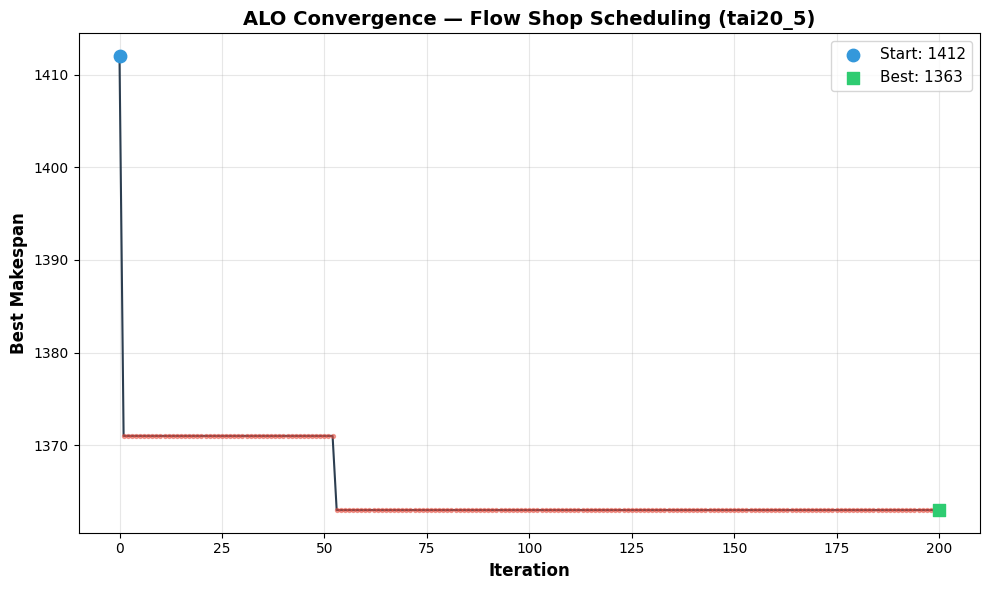

Initial makespan: 1412
Final makespan:   1363
Improvement:      3.47%


In [13]:
# =============================================================================
# Cell 26 — Convergence Curve
# =============================================================================

plt.figure(figsize=(10, 6))
plt.plot(convergence, color='#2c3e50', linewidth=1.5)
plt.scatter(range(len(convergence)), convergence,
            color='#e74c3c', s=8, alpha=0.5, zorder=5)
plt.scatter(0, convergence[0], color='#3498db', s=80,
            marker='o', label=f'Start: {convergence[0]:.0f}', zorder=10)
plt.scatter(len(convergence)-1, convergence[-1], color='#2ecc71', s=80,
            marker='s', label=f'Best: {convergence[-1]:.0f}', zorder=10)

plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Best Makespan', fontsize=12, fontweight='bold')
plt.title('ALO Convergence — Flow Shop Scheduling (tai20_5)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Initial makespan: {convergence[0]:.0f}")
print(f"Final makespan:   {convergence[-1]:.0f}")
print(f"Improvement:      {((convergence[0] - convergence[-1]) / convergence[0] * 100):.2f}%")

## Part 14 — Gantt Chart

A Gantt chart visualizes the schedule: each job is a horizontal bar across the machines, showing when each operation starts and ends. This helps verify that the schedule is valid and interpret the makespan.

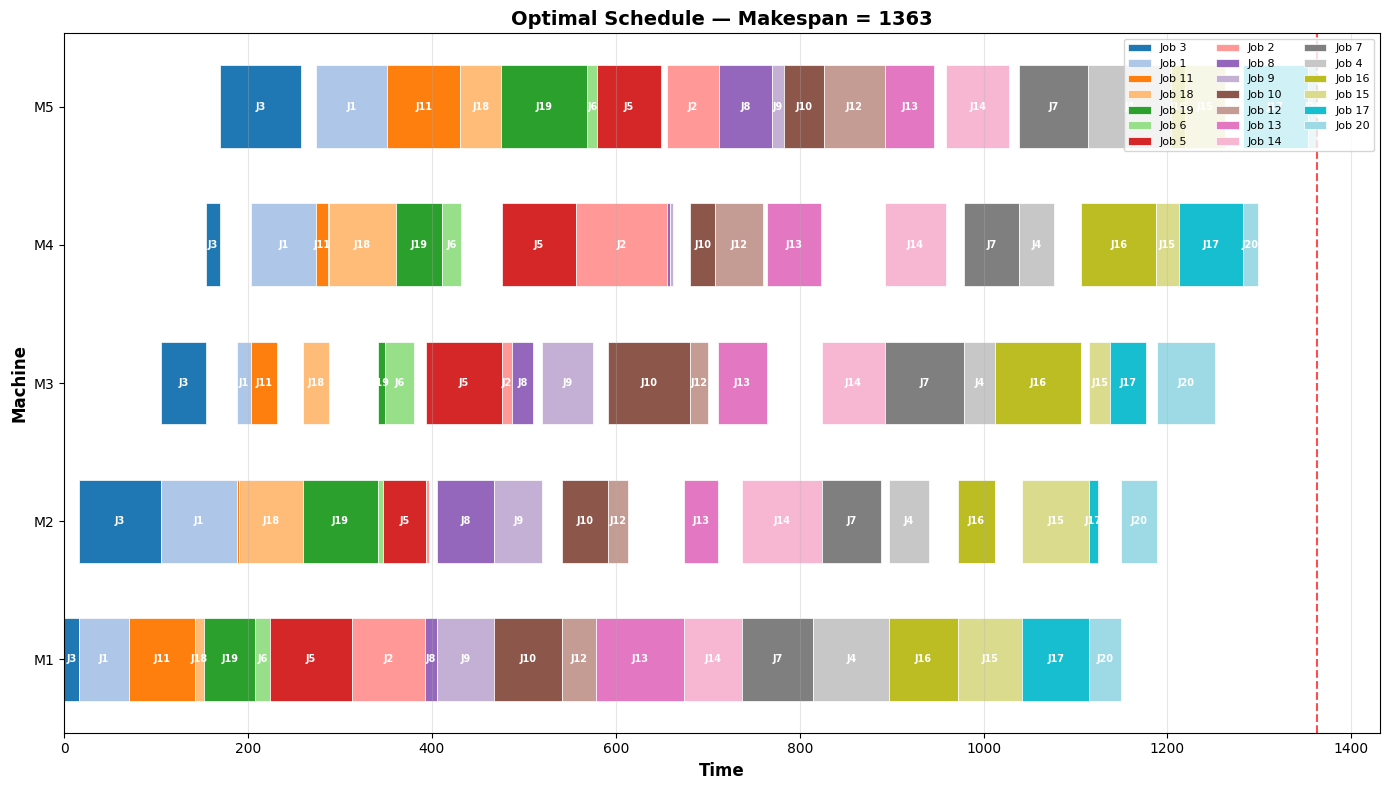

In [14]:
# =============================================================================
# Cell 28 — Gantt Chart for Best Schedule
# =============================================================================

def plot_gantt_chart(schedule, processing_times, completion_times, figsize=(14, 8)):
    """
    Plot a Gantt chart of the schedule.

    Each job is assigned a unique color. Horizontal bars show the duration
    of each operation on each machine.

    Parameters
    ----------
    schedule : ndarray
        Job permutation (0-based)
    processing_times : ndarray of shape (n_jobs, n_machines)
        Processing time matrix
    completion_times : ndarray of shape (n_jobs, n_machines)
        Completion time matrix (from calculate_makespan)
    figsize : tuple
        Figure dimensions
    """
    n_jobs = len(schedule)
    n_machines = processing_times.shape[1]

    # Calculate start times from completion times
    start_times = completion_times - processing_times[schedule]

    # Create color map for jobs
    colors = plt.cm.tab20(np.linspace(0, 1, n_jobs))

    fig, ax = plt.subplots(figsize=figsize)

    for j in range(n_jobs):
        job_idx = schedule[j]  # original job index
        for k in range(n_machines):
            start = start_times[j, k]
            duration = processing_times[job_idx, k]
            ax.barh(
                y=k,
                width=duration,
                left=start,
                height=0.6,
                color=colors[j % len(colors)],
                edgecolor='white',
                linewidth=0.5,
                label=f'Job {job_idx + 1}' if k == 0 else ''
            )
            # Add job label in the middle of each bar (if space permits)
            if duration > max(processing_times.max() * 0.08, 1):
                ax.text(
                    start + duration / 2, k,
                    f'J{job_idx + 1}',
                    ha='center', va='center',
                    fontsize=7, fontweight='bold',
                    color='white'
                )

    ax.set_xlabel('Time', fontsize=12, fontweight='bold')
    ax.set_ylabel('Machine', fontsize=12, fontweight='bold')
    ax.set_title(f'Optimal Schedule — Makespan = {completion_times[-1, -1]:.0f}',
                 fontsize=14, fontweight='bold')
    ax.set_yticks(range(n_machines))
    ax.set_yticklabels([f'M{k + 1}' for k in range(n_machines)])
    ax.grid(True, axis='x', alpha=0.3)
    ax.legend(loc='upper right', fontsize=8, ncol=3)

    # Mark makespan
    makespan = completion_times[-1, -1]
    ax.axvline(x=makespan, color='red', linestyle='--', linewidth=1.5,
               alpha=0.7, label=f'C_max = {makespan:.0f}')

    plt.tight_layout()
    plt.show()


# --- Plot Gantt chart for the best schedule ---
best_completion = results['best_completion_times']
plot_gantt_chart(best_schedule, processing_times, best_completion)

## Part 15 — Results Summary

| Metric | Value |
|---|---|
| Problem | $n_{\text{jobs}} \times n_{\text{machines}}$ |
| Algorithm | Ant Lion Optimizer (Mirjalili, 2015) |
| Adaptation | Random Keys + Makespan |
| Best Makespan | |
| Improvement | |
| Execution Time | |

This notebook reproduces the original ALO algorithm while adapting it to the Permutation Flow Shop Scheduling Problem. The only modifications from Mirjalili's continuous ALO are:
1. **Random Keys**: continuous position → job permutation via argsort
2. **Makespan**: permutation → $C_{\max}$ instead of an objective function

Everything else — random walk, roulette wheel, elite, replacement, shrinking boundaries — is **100% faithful** to Mirjalili's paper.